# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler # Menggunakan RobustScaler karena data sensor sering memiliki outlier
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

## 3.1 Download Data

In [ ]:
import os
# Base Dir
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Bikin folder untuk simpan data
os.makedirs("../predictive_maintenance_raw", exist_ok=True)

# 1. Masukkan token Kaggle
os.environ['KAGGLE_API_TOKEN'] = input("Masukkan token Kaggle: ")

# 2. Download dataset langsung dari link Kaggle
!kaggle datasets download -d shivamb/machine-predictive-maintenance-classification -p ../predictive_maintenance_raw

# 3. Ekstrak (unzip) dataset yang baru saja didownload
import zipfile

with zipfile.ZipFile(os.path.join(BASE_DIR, "predictive_maintenance_raw", "machine-predictive-maintenance-classification.zip"), 'r') as zip_ref:
    zip_ref.extractall(os.path.join(BASE_DIR, "predictive_maintenance_raw"))


Disini saya mengambil Machine Predictive Maintenance Classification Dataset yang terdiri dari 10.000 data point yang disimpan sebagai baris dengan 14 fitur dalam 

kolom:
- **UID**: pengenal unik yang berkisar dari 1 hingga 10000
- **productID**: terdiri dari huruf L, M, atau H untuk varian kualitas produk rendah (50% dari semua produk), sedang (30%), dan tinggi (20%) serta nomor seri khusus varian
- **air temperature [K]**: dihasilkan menggunakan proses random walk kemudian dinormalisasi ke standar deviasi 2 K sekitar 300 K
- **process temperature [K]**: dihasilkan menggunakan proses random walk dinormalisasi ke standar deviasi 1 K, ditambahkan ke suhu udara plus 10 K.
- **rotational speed [rpm]**: dihitung dari daya 2860 W, ditumpangi dengan noise yang didistribusikan secara normal
- **torque [Nm]**: nilai torsi didistribusikan secara normal sekitar 40 Nm dengan σ = 10 Nm dan tidak ada nilai negatif.
- **keausan alat [min]**: Varian kualitas H/M/L menambahkan 5/3/2 menit keausan alat pada alat yang digunakan dalam proses. dan label 'kegagalan mesin' yang menunjukkan, apakah mesin telah gagal dalam data point tertentu ini untuk salah satu dari mode kegagalan berikut benar.
- **tool wear [min]**: Variasi kualitas H/M/L menambahkan 5/3/2 menit ke penggunaan alat dalam proses. dan sebuah
'machine failure' label yang menunjukkan, apakah mesin telah mengalami kegagalan dalam data tertentu untuk satu atau lebih mode kegagalan yang berikut adalah benar.

In [10]:
# 4. Baca dataset menggunakan library Pandas
import pandas as pd
import os
# Base Dir
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), os.pardir))# Load CSV ke dalam DataFrame
df = pd.read_csv(os.path.join(BASE_DIR, "predictive_maintenance_raw", "predictive_maintenance.csv"))

# Tampilkan informasi tentang DataFrame
print("Dimensi data:", df.shape)

# Tampilkan 5 baris pertama
df.head(50)

Dimensi data: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

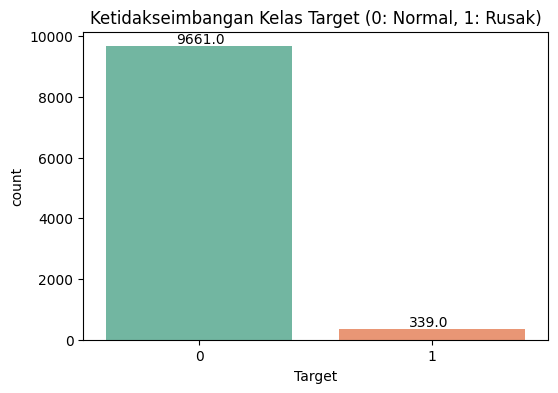

Terlihat jelas bahwa data ini sangat imbalanced (rusak sangat sedikit).


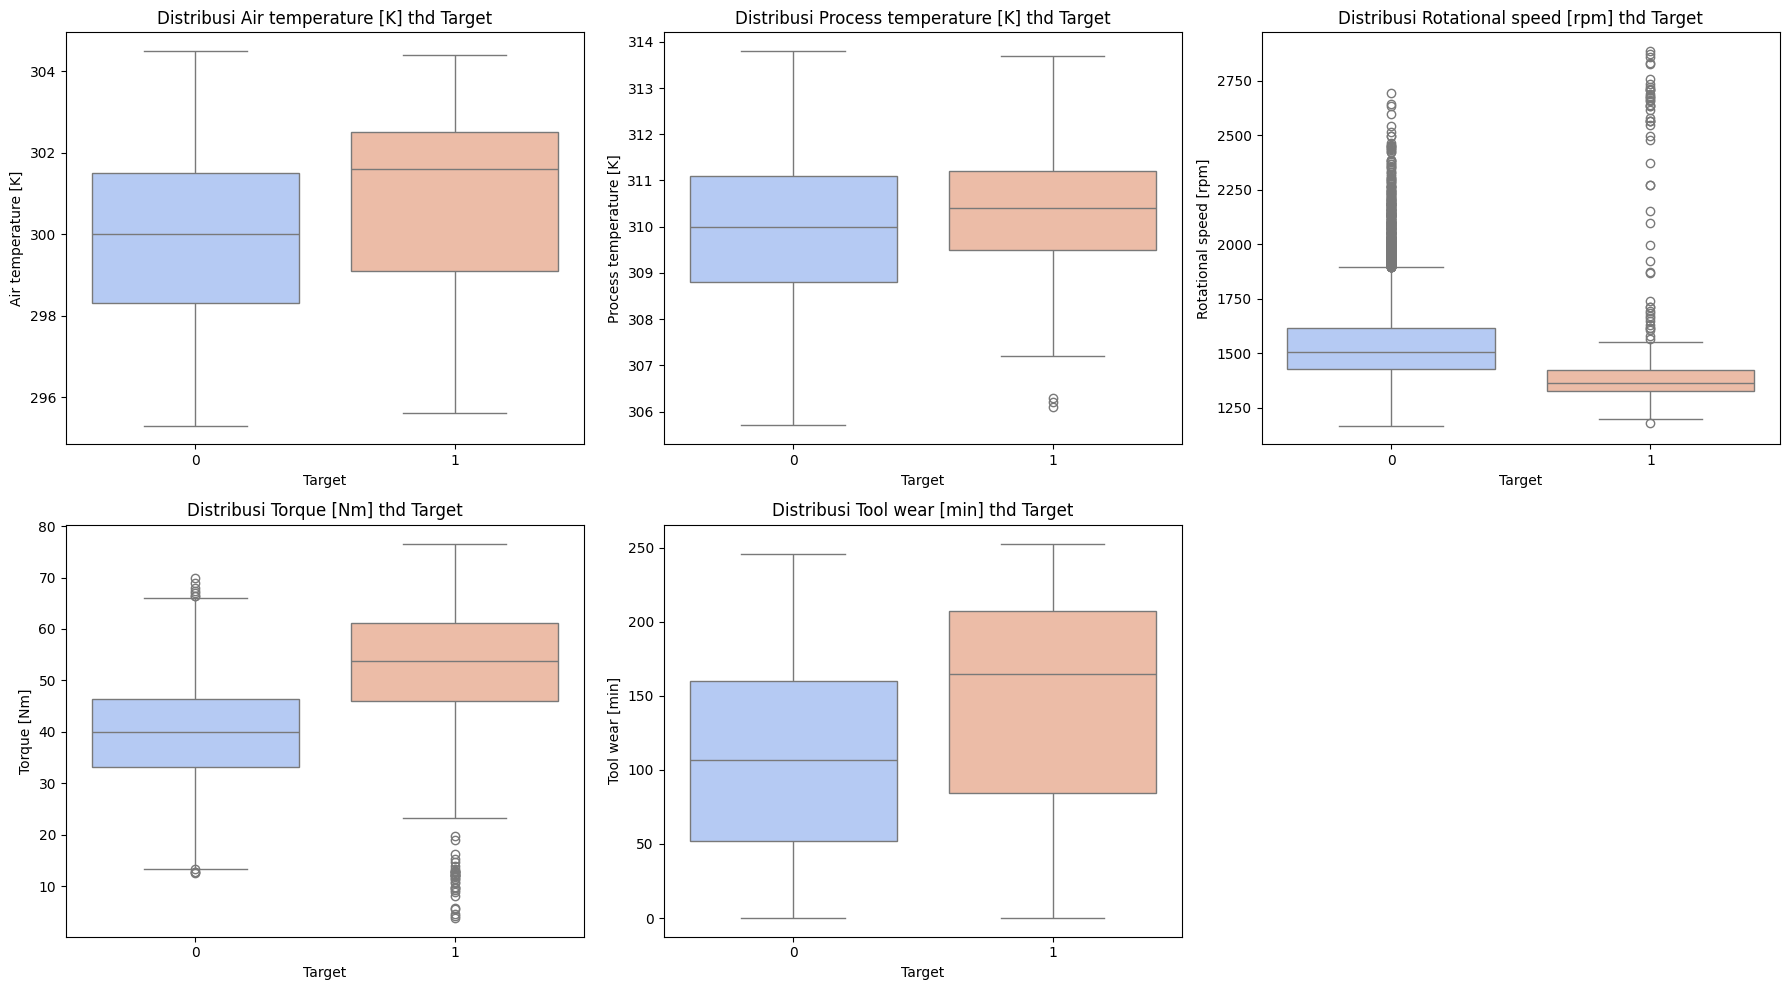

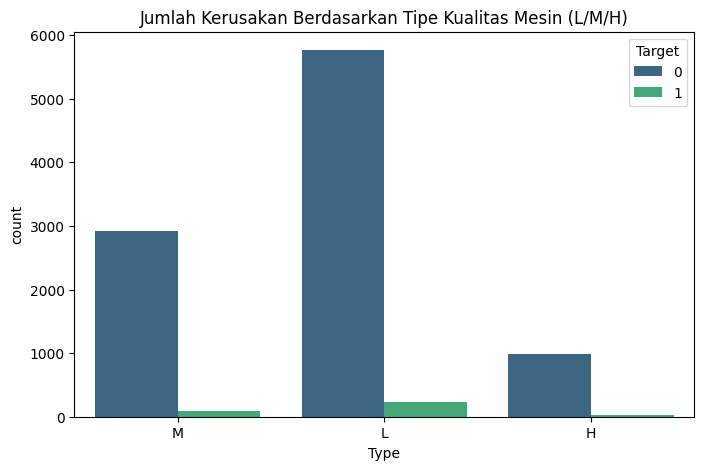

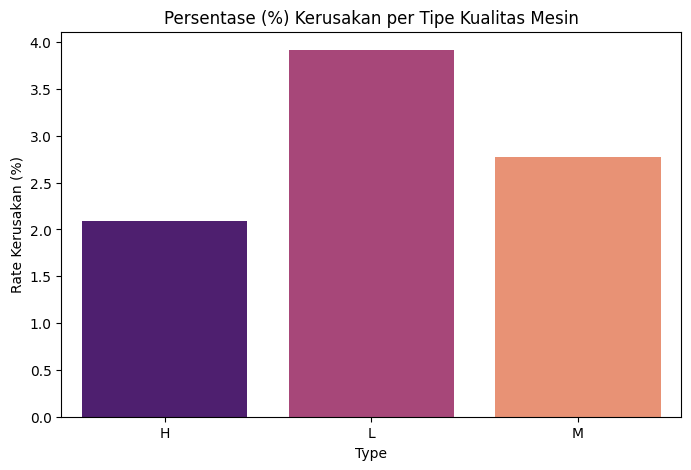

In [5]:
# 1. Analisis Proporsi Kelas Target
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Target', palette='Set2')
plt.title('Ketidakseimbangan Kelas Target (0: Normal, 1: Rusak)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 100))
plt.show()
print("Terlihat jelas bahwa data ini sangat imbalanced (rusak sangat sedikit).")

# 2. Distribusi Fitur Numerik Berdasarkan Target (Boxplot)
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Distribusi {col} thd Target')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 3. Analisis Kategori (Tipe Mesin vs Kerusakan)
# Plot A: Jumlah Absolut
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Type', hue='Target', palette='viridis')
plt.title('Jumlah Kerusakan Berdasarkan Tipe Kualitas Mesin (L/M/H)')
plt.show()

# Plot B: Proporsi (%) Kerusakan per Tipe
type_failure_rate = df.groupby('Type')['Target'].value_counts(normalize=True).rename('percentage').reset_index()
type_failure_rate['percentage'] *= 100

plt.figure(figsize=(8, 5))
sns.barplot(data=type_failure_rate[type_failure_rate['Target'] == 1], x='Type', y='percentage', palette='magma')
plt.title('Persentase (%) Kerusakan per Tipe Kualitas Mesin')
plt.ylabel('Rate Kerusakan (%)')
plt.show()

### Kesimpulan Analisis Exploratory Data Analysis (EDA)

Berdasarkan visualisasi data di atas, kita dapat menarik beberapa *insight* krusial yang akan menjadi landasan untuk tahap *preprocessing* dan pemodelan:

**1. Ketidakseimbangan Kelas (Class Imbalance) yang Ekstrem**
* Dari *countplot*, terlihat dominasi kelas yang sangat masif pada `Target 0` (Normal) sebanyak 9.661 sampel, berbanding terbalik dengan `Target 1` (Rusak) yang hanya memiliki 339 sampel (~3.3% dari total data).
* **Implikasi:** Kita tidak bisa menggunakan metrik **Akurasi (Accuracy)** untuk mengevaluasi model nanti, karena model yang menebak "Normal" terus-menerus akan otomatis mendapat akurasi 96%. Evaluasi model wajib menggunakan metrik yang lebih kebal terhadap *imbalanced data*, seperti **F1-Score, Precision, Recall, atau ROC-AUC**.

**2. Indikator Kuat Kerusakan Mesin (Berdasarkan Boxplot)**
* **Torque (Torsi) & Tool wear (Keausan):** Terdapat perbedaan distribusi yang sangat mencolok. Mesin yang rusak (`Target 1`) rata-rata beroperasi pada tingkat torsi yang jauh lebih tinggi dan tingkat keausan alat yang lebih lama dibandingkan mesin normal. Dua fitur ini akan menjadi prediktor utama (fitur terpenting) bagi model *Machine Learning*.
* **Rotational speed (Kecepatan Rotasi):** Menunjukkan korelasi negatif. Mesin yang rusak cenderung memiliki rata-rata kecepatan rotasi yang lebih rendah dibandingkan mesin normal. Selain itu, terdapat banyak sekali *outlier* (titik-titik di luar kumis *boxplot*), yang menegaskan perlunya penggunaan **RobustScaler** pada tahap *preprocessing*.
* **Suhu (Air & Process Temperature):** Perbedaan median antara mesin normal dan rusak tidak terlalu radikal dan rentangnya banyak beririsan (*overlapping*). Hal ini mengindikasikan bahwa suhu yang berdiri sendiri kurang kuat untuk memprediksi kerusakan, sehingga menjustifikasi langkah kita sebelumnya untuk membuat fitur baru (*Feature Engineering*) berupa selisih suhu (`Temp_Difference`).

**3. Korelasi Tipe Kualitas Mesin terhadap Risiko Kerusakan**
* Berdasarkan *barplot* proporsi kerusakan, populasi mesin di pabrik didominasi oleh tipe **L (Low Quality)**, yang secara absolut menyumbang angka kerusakan (`Target 1`) paling tinggi. Sebaliknya, mesin tipe **H (High Quality)** memiliki populasi paling sedikit dan tingkat kerusakan yang sangat minim.
* **Implikasi:** Fitur `Type` memiliki hierarki risiko yang logis (L berisiko lebih tinggi dari M, dan M lebih berisiko dari H). Hal ini memvalidasi keputusan *Preprocessing* kita untuk menggunakan **Ordinal Encoding** (misalnya L=0, M=1, H=2) alih-alih *One-Hot Encoding*. Dengan begitu, model dapat mempelajari pola linear bahwa kualitas mesin yang lebih rendah berkorelasi dengan probabilitas *failure* yang lebih tinggi.

**4. Kesimpulan Strategi Pemodelan**
Pola-pola mekanis ini (Torsi tinggi diiringi rotasi rendah pada mesin tipe rendah) sangat masuk akal secara prinsip fisika industri. Oleh karena itu, penciptaan fitur interaksi seperti estimasi Daya (`Power = Torque * Rotational speed`) pada tahap *Feature Engineering* diharapkan dapat menangkap sinyal kerusakan ini dengan lebih tajam.

--- Pengecekan Asumsi Normalitas Distribusi Data ---
Tujuan: Membuktikan apakah fitur numerik berdistribusi normal atau condong (skewed).
Hal ini untuk menjustifikasi penggunaan uji non-parametrik (Mann-Whitney).

Fitur: Air temperature [K]
  -> Skewness: 0.114 (Idealnya mendekati 0 jika normal)
  -> Shapiro p-value: 1.30182e-34 (< 0.05 berarti TIDAK normal)

Fitur: Process temperature [K]
  -> Skewness: 0.015 (Idealnya mendekati 0 jika normal)
  -> Shapiro p-value: 1.03023e-22 (< 0.05 berarti TIDAK normal)

Fitur: Rotational speed [rpm]
  -> Skewness: 1.993 (Idealnya mendekati 0 jika normal)
  -> Shapiro p-value: 2.10405e-68 (< 0.05 berarti TIDAK normal)

Fitur: Torque [Nm]
  -> Skewness: -0.010 (Idealnya mendekati 0 jika normal)
  -> Shapiro p-value: 3.82446e-01 (< 0.05 berarti TIDAK normal)

Fitur: Tool wear [min]
  -> Skewness: 0.027 (Idealnya mendekati 0 jika normal)
  -> Shapiro p-value: 6.23755e-46 (< 0.05 berarti TIDAK normal)



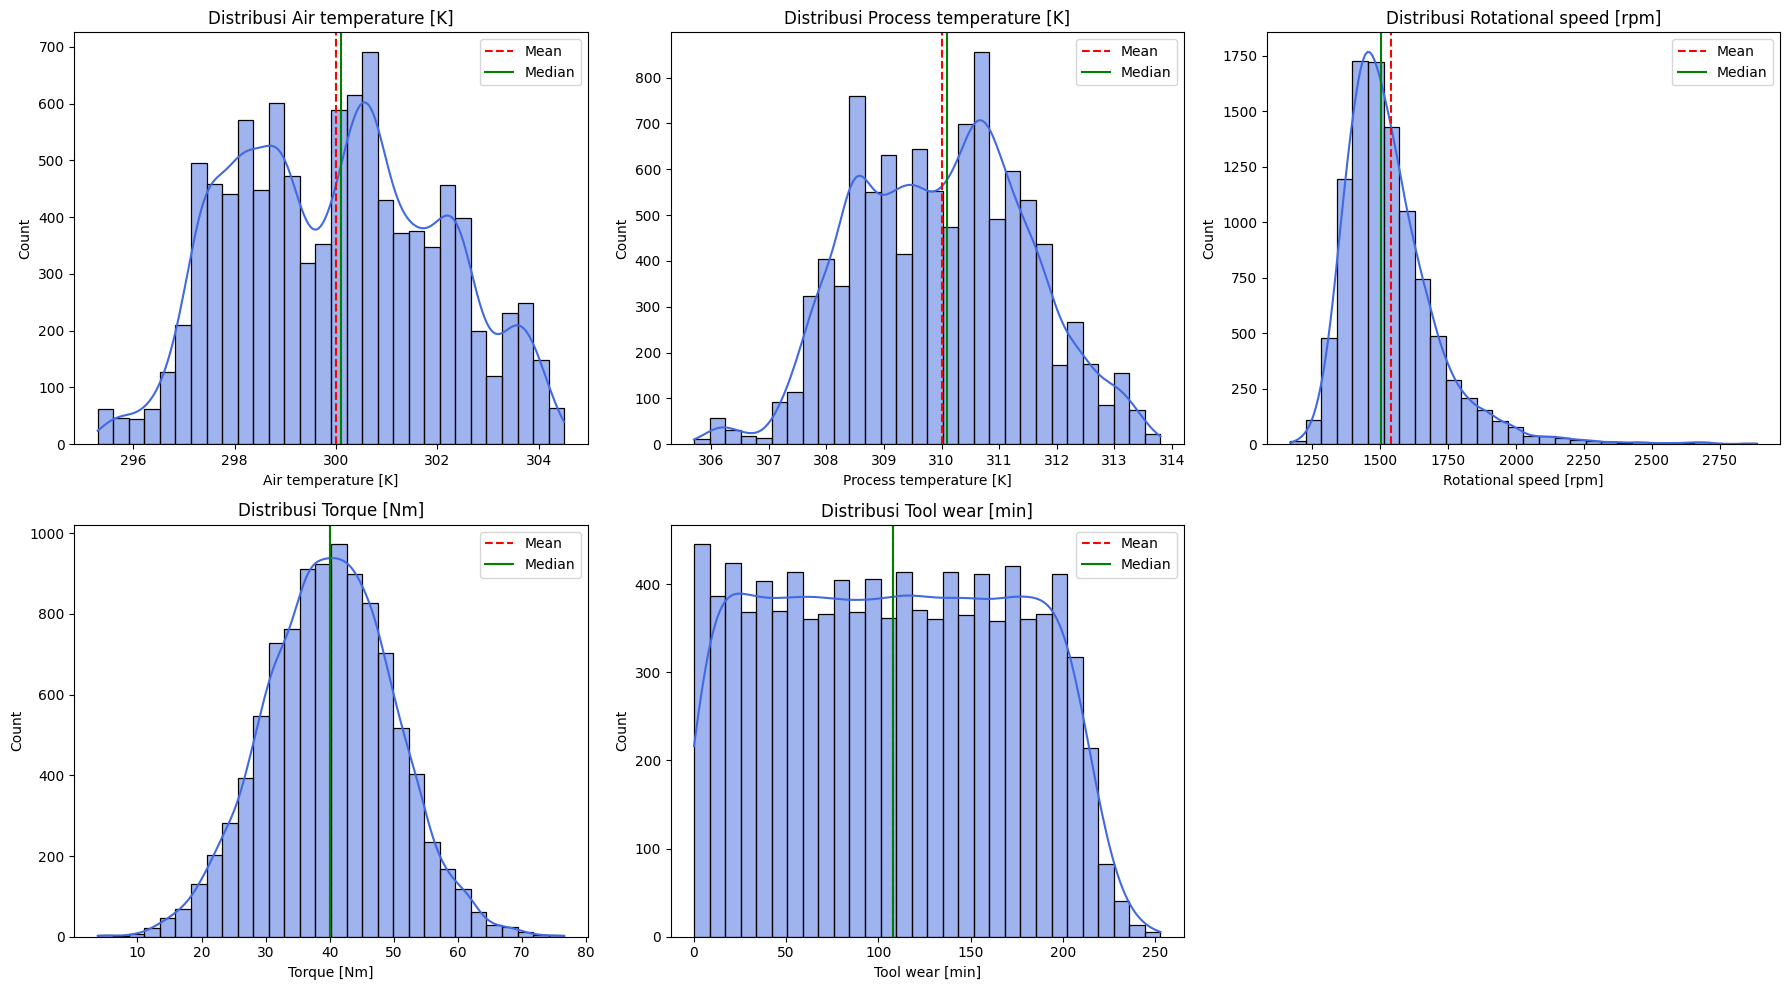

In [6]:
print("--- Pengecekan Asumsi Normalitas Distribusi Data ---")
print("Tujuan: Membuktikan apakah fitur numerik berdistribusi normal atau condong (skewed).")
print("Hal ini untuk menjustifikasi penggunaan uji non-parametrik (Mann-Whitney).\n")

numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# 1. PEMBUKTIAN SECARA STATISTIK (Skewness & Uji Shapiro-Wilk)
for col in numeric_features:
    # Menghitung nilai Skewness (Kecondongan)
    skewness = df[col].skew()

    # Melakukan Uji Shapiro-Wilk untuk Normalitas
    # (H0: Data berdistribusi normal. Jika p-value < 0.05, H0 ditolak -> data TIDAK normal)
    stat, p_value = stats.shapiro(df[col])

    print(f"Fitur: {col}")
    print(f"  -> Skewness: {skewness:.3f} (Idealnya mendekati 0 jika normal)")
    print(f"  -> Shapiro p-value: {p_value:.5e} (< 0.05 berarti TIDAK normal)\n")

# 2. PEMBUKTIAN SECARA VISUAL (Histogram dengan kurva KDE)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    # Plot histogram dengan kurva kepadatan (KDE)
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', bins=30)
    axes[i].set_title(f'Distribusi {col}')

    # Menambahkan garis vertikal untuk Mean dan Median
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='-', label='Median')
    axes[i].legend()

fig.delaxes(axes[5]) # Menghapus plot ke-6 yang kosong
plt.tight_layout()
plt.show()

### Kesimpulan Uji Normalitas:
Berdasarkan hasil uji statistik Shapiro-Wilk dan nilai *skewness* di atas, kita dapat menyimpulkan bahwa:
1. Mayoritas data sensor industri ini (**Air temp, Process temp, Rotational speed, Tool wear**) memiliki nilai *p-value* jauh di bawah 0.05, yang membuktikan bahwa datanya **TIDAK berdistribusi normal**.
2. Terjadi anomali ekstrem pada `Rotational speed` (*skewness* ~ 1.99), yang menjustifikasi keharusan kita melakukan **Log Transform** pada tahap *preprocessing* nanti.
3. Meskipun `Torque` berdistribusi normal (*p-value* = 0.382 > 0.05), pendekatan pengujian statistik terbaik dan paling aman untuk keseluruhan dataset ini adalah menggunakan uji non-parametrik, yaitu **Mann-Whitney U Test**.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
df_clean = df.copy()

# 1. Menghapus Kolom yang Tidak Memberikan Pola General
# UDI dan Product ID unik untuk setiap baris, Failure Type bocoran dari Target (Data Leakage)
df_clean = df_clean.drop(['UDI', 'Product ID', 'Failure Type'], axis=1)

# 2. FEATURE ENGINEERING (Menciptakan Sinyal Baru)
# A. Selisih Suhu: Suhu proses mesin dikurangi suhu udara sekitar
df_clean['Temp_Difference'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']

# B. Estimasi Daya (Power): Torsi dikali Kecepatan Rotasi
df_clean['Power'] = df_clean['Torque [Nm]'] * df_clean['Rotational speed [rpm]']

# C. Rasio Ketegangan Mesin (Strain): Tool wear dikali Rotational speed
df_clean['Strain'] = df_clean['Tool wear [min]'] * df_clean['Rotational speed [rpm]']

print("Fitur baru berhasil dibuat: Temp_Difference, Power, dan Strain.")

# 3. FEATURE SELECTION (Mencegah Multikolinearitas)

df_clean = df_clean.drop(['Air temperature [K]', 'Process temperature [K]'], axis=1)
print("Fitur suhu asli dihapus untuk mencegah multikolinearitas.")

# 4. ENCODING DATA KATEGORIKAL
# Kolom 'Type' memiliki tingkatan kualitas: Low (L), Medium (M), High (H).
type_mapping = {'L': 0, 'M': 1, 'H': 2}
df_clean['Type'] = df_clean['Type'].map(type_mapping)

# 5. TRANSFORMASI LOGARITMIK (Handling Skewed Data)
# Berdasarkan Uji Shapiro-Wilk, fitur rotasi dan turunannya sangat condong (right-skewed).
# Kita gunakan np.log1p (log(1+x)) untuk menormalkan distribusinya.
skewed_cols = ['Rotational speed [rpm]', 'Tool wear [min]', 'Power', 'Strain']
for col in skewed_cols:
    df_clean[col] = np.log1p(df_clean[col])
print("Log transformation diaplikasikan pada fitur yang memiliki skewness tinggi.")

# 6. PEMISAHAN FITUR (X) DAN TARGET (y)
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

# Train test split dilakukan di modelling untuk menjaga konsistensi dengan pipeline modelling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. SCALING (Standardisasi Tahan Outlier)
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Tampilkan preview data
df_final = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)  
display(df_final.head())
print("Data Preprocessing Komprehensif Selesai! Data siap dilatih.")

Fitur baru berhasil dibuat: Temp_Difference, Power, dan Strain.
Fitur suhu asli dihapus untuk mencegah multikolinearitas.
Log transformation diaplikasikan pada fitur yang memiliki skewness tinggi.


,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Difference,Power,Strain,Target
0,1.0,-0.252077,0.522059,-0.607443,-0.529412,0.591651,-0.644762,0
1,1.0,-0.568932,0.463235,0.187435,0.882353,0.346216,0.113624,0
2,1.0,-0.810771,0.404412,0.220656,0.470588,0.140188,0.119572,0
3,0.0,-0.501167,1.191176,-0.215576,0.647059,1.215276,-0.280227,0
4,0.0,1.129850,-0.838235,-0.675414,0.941176,-0.799865,-0.558433,0


Data Preprocessing Komprehensif Selesai! Data siap dilatih.
